# Experiment 01: First Classification Model

## Objective
Learn the basic structure of a supervised machine learning problem.

## Background
A machine learning classification problem starts with examples, inputs, and correct answers.

For this first experiment, I am using a simple synthetic dataset so I can focus on the workflow without extra complexity.

## Core concepts
- **Dataset**: a collection of examples
- **Feature**: an input value used for prediction
- **Label**: the correct answer
- **Model**: a system that learns patterns from data
- **Training set**: the part of the data used to teach the model
- **Test set**: the part of the data used to evaluate the model

## Plan
In this notebook, I will:
1. Generate a simple synthetic dataset
2. Split the data into training and test sets
3. Train a basic classifier
4. Make predictions
5. Measure accuracy

## Working idea
A simple classifier trained on a clear dataset should help me understand the core machine learning workflow before moving on to harder topics like imbalance and risk-sensitive evaluation.

In [25]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

In [26]:
x, y = make_classification(n_samples=1000, n_features=2, n_informative=2, n_redundant=0, n_clusters_per_class=1, random_state=42, weights=[0.5, 0.5])
print("Shape of x:", x.shape)
print("Shape of y:", y.shape) 
unique, counts = np.unique(y, return_counts=True)

class_counts = {int(k): int(v) for k, v in zip(unique, counts)}
print("Class counts:", class_counts)


Shape of x: (1000, 2)
Shape of y: (1000,)
Class counts: {0: 501, 1: 499}


In [27]:


print("First 5 rows of x:")
print(x[:5])

print("\nFirst 5 labels:")
print(y[:5])

First 5 rows of x:
[[ 0.60103418  1.5353525 ]
 [ 0.75594526 -1.1723519 ]
 [ 1.35447877 -0.94852841]
 [ 3.1030897   0.23348484]
 [ 0.75317779  0.78751427]]

First 5 labels:
[1 0 0 0 1]


In [28]:
x_train, x_test, y_train, y_test = train_test_split(
    x,
    y,
    test_size=0.2,
    random_state=42
)

print("Training feature shape:", x_train.shape)
print("Test feature shape:", x_test.shape)

print("Training labels shape:", y_train.shape)
print("Test labels shape:", y_test.shape)

Training feature shape: (800, 2)
Test feature shape: (200, 2)
Training labels shape: (800,)
Test labels shape: (200,)


In [29]:
model = LogisticRegression()

model.fit(x_train, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [30]:
y_pred = model.predict(x_test)

print("First 10 predictions:", y_pred[:10])

First 10 predictions: [1 0 0 0 0 1 0 1 0 0]


In [31]:
accuracy = accuracy_score(y_test, y_pred)

print("Model accuracy:", accuracy)

Model accuracy: 0.9


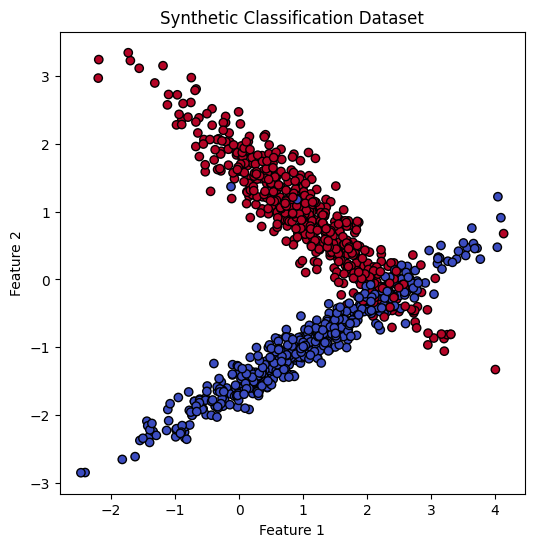

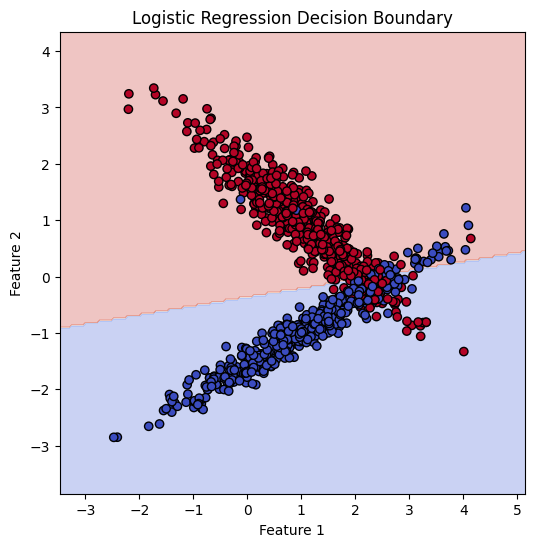

In [34]:
plt.figure(figsize=(6,6))

plt.scatter(
    x[:,0],
    x[:,1],
    c=y,
    cmap="coolwarm",
    edgecolor="k"
)

plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.title("Synthetic Classification Dataset")

plt.show()

# Create a grid of points covering the feature space
x_min, x_max = x[:, 0].min() - 1, x[:, 0].max() + 1
y_min, y_max = x[:, 1].min() - 1, x[:, 1].max() + 1

xx, yy = np.meshgrid(
    np.linspace(x_min, x_max, 200),
    np.linspace(y_min, y_max, 200)
)

# Combine the grid points into feature pairs
grid_points = np.c_[xx.ravel(), yy.ravel()]

# Ask the trained model to predict the class for each grid point
Z = model.predict(grid_points)

# Reshape predictions back into grid shape
Z = Z.reshape(xx.shape)

# Plot decision regions
plt.figure(figsize=(6,6))

plt.contourf(xx, yy, Z, alpha=0.3, cmap="coolwarm")

# Plot the original dataset points
plt.scatter(
    x[:,0],
    x[:,1],
    c=y,
    cmap="coolwarm",
    edgecolor="k"
)

plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.title("Logistic Regression Decision Boundary")

plt.show()